In [1]:
import pandas as pd
import numpy as np
from datetime import timedelta

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [2]:
import pandas as pd
import os

# Define the base directory where your files are located
base_path = '/kaggle/input/health-care-mimic/'

# List of files to read
files = [
    'labs.csv', 'meds.csv', 'numerics.csv', 'orders.csv', 'pmh.csv',
    'rads.csv', 'split_chrono_test.csv', 'split_chrono_train.csv',
    'split_chrono_val.csv', 'split_random_test.csv', 'split_random_train.csv',
    'split_random_val.csv', 'visits.csv', 'waveform_summary.csv'
]

# Dictionary to store the dataframes if you want to access them later
dataframes = {}

for file_name in files:
    file_path = os.path.join(base_path, file_name)
    
    # Check if the file exists before trying to read it
    if os.path.exists(file_path):
        print(f"\n{'='*20} Reading: {file_name} {'='*20}")
        
        # Read the CSV
        df = pd.read_csv(file_path)
        
        # Store in dictionary (the key is the filename without .csv)
        dataframes[file_name.replace('.csv', '')] = df
        
        # Print info and head
        print(df.info())
        display(df.head()) # Use display() in Kaggle/Jupyter for better formatting
    else:
        print(f"Warning: {file_name} not found at {file_path}")


==================== Reading: labs.csv ====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5706470 entries, 0 to 5706469
Data columns (total 12 columns):
 #   Column              Dtype  
---  ------              -----  
 0   CSN                 int64  
 1   Order_time          object 
 2   Result_time         object 
 3   Display_name        object 
 4   Abnormal            object 
 5   Component_name      object 
 6   Component_result    object 
 7   Component_value     object 
 8   Component_units     object 
 9   Component_abnormal  object 
 10  Component_nml_low   float64
 11  Component_nml_high  float64
dtypes: float64(2), int64(1), object(9)
memory usage: 522.4+ MB
None


,CSN,Order_time,Result_time,Display_name,Abnormal,Component_name,Component_result,Component_value,Component_units,Component_abnormal,Component_nml_low,Component_nml_high
0,99370369,2253-07-16T00:25:57Z,2253-07-16T01:21:57Z,"Metabolic Panel, Comprehensive",Abnormal,SODIUM,142,142,mmol/L,Normal,135.0,145.0
1,99370369,2253-07-16T00:25:57Z,2253-07-16T01:52:57Z,RAPID COVID (aka Rapid Coronavirus 2019 (SARS-...,NaN,SARS-COV-2 RNA,Not Detected,1,NaN,Normal,NaN,NaN
2,99370369,2253-07-16T00:25:57Z,2253-07-16T01:21:57Z,"Metabolic Panel, Comprehensive",Abnormal,CHLORIDE,103,103,mmol/L,Normal,98.0,107.0
3,99370369,2253-07-16T00:25:57Z,2253-07-16T01:21:57Z,"Metabolic Panel, Comprehensive",Abnormal,ANION GAP,12,12,mmol/L,Normal,5.0,15.0
4,99370369,2253-07-16T00:25:57Z,2253-07-16T01:21:57Z,"Metabolic Panel, Comprehensive",Abnormal,ALKALINE PHOSPHATASE,99,99,U/L,Normal,35.0,105.0



==================== Reading: meds.csv ====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235718 entries, 0 to 235717
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   MRN           235718 non-null  int64 
 1   Med_ID        235718 non-null  int64 
 2   NDC           134579 non-null  object
 3   Name          235718 non-null  object
 4   Generic_name  229976 non-null  object
 5   Med_class     230747 non-null  object
 6   Med_subclass  230151 non-null  object
 7   Active        72684 non-null   object
 8   Entry_date    235718 non-null  object
 9   Start_date    80232 non-null   object
 10  End_date      112607 non-null  object
dtypes: int64(2), object(9)
memory usage: 19.8+ MB
None


,MRN,Med_ID,NDC,Name,Generic_name,Med_class,Med_subclass,Active,Entry_date,Start_date,End_date
0,98816154,3774,63739-486-10,HYDROXYZINE HCL 25 MG PO TABS,hydrOXYzine HCL 25 mg tablet,ANTIHISTAMINES - 1ST GENERATION,Antianxiety Agent - Antihistamine Type,NaN,2296-03-29T00:00:00Z,2296-02-10T00:00:00Z,2299-03-13T00:00:00Z
1,98816154,4572,63739-499-10,LORAZEPAM 0.5 MG PO TABS,LORazepam 0.5 mg tablet,ANTI-ANXIETY - BENZODIAZEPINES,Antianxiety Agent - Benzodiazepines,NaN,2296-06-06T00:00:00Z,2296-05-18T00:00:00Z,2299-03-13T00:00:00Z
2,98816154,8901,NaN,ZOLOFT 100 MG PO TABS,sertraline 100 mg tablet,SELECTIVE SEROTONIN REUPTAKE INHIBITOR (SSRIS),Antidepressant - Selective Serotonin Reuptake ...,NaN,2297-09-30T00:00:00Z,NaN,2299-03-13T00:00:00Z
3,98816154,116051,65862-662-30,ARIPIPRAZOLE 5 MG PO TABS,ARIPiprazole 5 mg tablet,"ANTIPSYCHOTICS, ATYP, D2 PARTIAL AGONIST/5HT M...",Bipolar Therapy Agents - Atypical Antipsychotics,NaN,2296-06-06T00:00:00Z,2296-06-01T00:00:00Z,2299-03-03T00:00:00Z
4,98816154,198710,0904-6935-61,PALIPERIDONE 3 MG PO TR24,"paliperidone ER 3 mg tablet,extended release 2...","ANTIPSYCHOTIC,ATYPICAL,DOPAMINE,SEROTONIN ANTA...",Antipsychotic - Atypical Dopamine-Serotonin An...,NaN,2296-06-06T00:00:00Z,2296-05-18T00:00:00Z,2299-03-03T00:00:00Z



==================== Reading: numerics.csv ====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47821508 entries, 0 to 47821507
Data columns (total 5 columns):
 #   Column   Dtype  
---  ------   -----  
 0   CSN      int64  
 1   Source   object 
 2   Measure  object 
 3   Value    float64
 4   Time     object 
dtypes: float64(1), int64(1), object(3)
memory usage: 1.8+ GB
None


...

,99603825
0,99908562
1,99892292
2,99259539
3,99239771
4,99397723



==================== Reading: visits.csv ====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118385 entries, 0 to 118384
Data columns (total 33 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   MRN                     118385 non-null  int64  
 1   CSN                     118385 non-null  int64  
 2   Visit_no                118385 non-null  int64  
 3   Visits                  118385 non-null  int64  
 4   Age                     118385 non-null  int64  
 5   Gender                  118385 non-null  object 
 6   Race                    118009 non-null  object 
 7   Ethnicity               118009 non-null  object 
 8   Means_of_arrival        118385 non-null  object 
 9   Triage_Temp             108888 non-null  float64
 10  Triage_HR               118231 non-null  float64
 11  Triage_RR               118200 non-null  float64
 12  Triage_SpO2             118166 non-null  float64
 13  Triage_SBP 

,MRN,CSN,Visit_no,Visits,Age,Gender,Race,Ethnicity,Means_of_arrival,Triage_Temp,...,Payor_class,Admit_service,Dx_ICD9,Dx_ICD10,Dx_name,Arrival_time,Roomed_time,Dispo_time,Admit_time,Departure_time
0,98880961,98874959,1,1,82,F,White,Non-Hispanic/Non-Latino,EMS,36.2,...,Medicare,Medicine,873.20,S01.21XA,"Laceration of nose, initial encounter",2283-03-02T07:36:59Z,2283-03-02T07:36:59Z,2283-03-02T12:29:59Z,2283-03-02T12:29:59Z,2283-03-02T13:44:59Z
1,99121566,99354408,1,2,59,F,Other,Non-Hispanic/Non-Latino,EMS,36.8,...,NaN,Emergency Medicine,780.97,R41.82,"Altered mental status, unspecified altered men...",2239-08-22T01:13:51Z,2239-08-22T01:16:51Z,2239-08-22T07:20:51Z,2239-08-22T07:20:51Z,2239-08-22T10:45:51Z
2,99121566,99121037,2,2,63,F,Other,Non-Hispanic/Non-Latino,EMS,37.2,...,NaN,Critical Care,"038.9, 785.52, 995.92","A41.9, R65.21",Septic shock (CMS-HCC),2240-03-11T03:06:51Z,2240-03-11T03:43:51Z,2240-03-11T08:31:51Z,2240-03-11T08:31:51Z,2240-03-11T13:37:51Z
3,99608739,99327434,1,2,90,F,White,Non-Hispanic/Non-Latino,Self,NaN,...,Medicare,NaN,729.81,M79.89,Leg swelling,2296-08-31T16:43:05Z,2296-08-31T17:56:05Z,2296-08-31T20:56:05Z,NaN,2296-08-31T21:06:05Z
4,99608739,99502864,2,2,89,F,White,Non-Hispanic/Non-Latino,Self,36.4,...,Medicare,NaN,788.20,R33.9,Urinary retention,2297-06-07T05:08:05Z,2297-06-07T05:59:05Z,2297-06-07T08:55:05Z,NaN,2297-06-07T09:35:05Z



==================== Reading: waveform_summary.csv ====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188315 entries, 0 to 188314
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   CSN       188315 non-null  int64  
 1   Type      188315 non-null  object 
 2   Segments  188315 non-null  int64  
 3   Duration  188315 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 5.7+ MB
None


,CSN,Type,Segments,Duration
0,99633476,II,1,2204.742
1,99633476,Resp,1,2234.096
2,99633476,Pleth,1,1873.120
3,99872476,Pleth,1,97.296
4,99960476,II,4,12818.304


In [3]:
!pip install -q transformers datasets xgboost shap


In [4]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier


In [5]:
waveforms = pd.read_csv("/kaggle/input/health-care-mimic/waveform_summary.csv")


In [7]:
waveforms.head()


,CSN,Type,Segments,Duration
0,99633476,II,1,2204.742
1,99633476,Resp,1,2234.096
2,99633476,Pleth,1,1873.120
3,99872476,Pleth,1,97.296
4,99960476,II,4,12818.304


In [8]:
wf_agg = waveforms.groupby("CSN").agg(
    total_segments=("Segments", "sum"),
    total_duration=("Duration", "sum"),
    n_waveform_types=("Type", "nunique")
).reset_index()


In [9]:
wf_types = pd.pivot_table(
    waveforms,
    index="CSN",
    columns="Type",
    values="Segments",
    aggfunc="count",
    fill_value=0
).reset_index()


In [10]:
# Binary presence (ECG, Pleth, Resp)
for col in wf_types.columns:
    if col != "CSN":
        wf_types[col] = (wf_types[col] > 0).astype(int)


In [11]:
wf_features = wf_agg.merge(wf_types, on="CSN", how="left")
wf_features = wf_features.fillna(0)


In [12]:
df = df.merge(wf_features, on="CSN", how="left")


In [13]:
WAVE_COLS = [
    "total_segments",
    "total_duration",
    "n_waveform_types"
]

# Add common waveform channels if present
for col in ["II", "Pleth", "Resp"]:
    if col in df.columns:
        WAVE_COLS.append(col)


In [16]:
STRUCT_COLS = [
    "Age",
    "Gender",
    "Means_of_arrival",
    "Triage_Temp",
    "Triage_HR",
    "Triage_RR",
    "Triage_SpO2",
    "Triage_SBP",
    "Triage_DBP"
]


In [17]:
FEATURES = STRUCT_COLS + WAVE_COLS


In [18]:
# ---------- Feature definitions ----------
STRUCT_COLS = [
    "Age",
    "Gender",
    "Means_of_arrival",
    "Triage_Temp",
    "Triage_HR",
    "Triage_RR",
    "Triage_SpO2",
    "Triage_SBP",
    "Triage_DBP"
]

WAVE_COLS = [
    "total_segments",
    "total_duration",
    "n_waveform_types"
]

for col in ["II", "Pleth", "Resp"]:
    if col in df.columns:
        WAVE_COLS.append(col)

FEATURES = STRUCT_COLS + WAVE_COLS


In [19]:
print("Number of features:", len(FEATURES))
print("Features:", FEATURES)


Number of features: 15
Features: ['Age', 'Gender', 'Means_of_arrival', 'Triage_Temp', 'Triage_HR', 'Triage_RR', 'Triage_SpO2', 'Triage_SBP', 'Triage_DBP', 'total_segments', 'total_duration', 'n_waveform_types', 'II', 'Pleth', 'Resp']


In [22]:
import os

BASE_PATH = "/kaggle/input"
print(os.listdir(BASE_PATH))


['health-care-mimic']


In [23]:
DATA = "/kaggle/input/health-care-mimic/"

split_train = pd.read_csv(DATA + "split_chrono_train.csv")
split_val   = pd.read_csv(DATA + "split_chrono_val.csv")
split_test  = pd.read_csv(DATA + "split_chrono_test.csv")

# Fix column names
split_train.columns = ["CSN"]
split_val.columns   = ["CSN"]
split_test.columns  = ["CSN"]

print("Train:", split_train.shape)
print("Val:", split_val.shape)
print("Test:", split_test.shape)


Train: (81587, 1)
Val: (11769, 1)
Test: (12019, 1)


In [24]:
def load_csv_safe(path, name):
    full_path = path + name
    if not os.path.exists(full_path):
        raise FileNotFoundError(f"{name} not found in {path}")
    return pd.read_csv(full_path)

split_train = load_csv_safe(DATA, "split_chrono_train.csv")
split_val   = load_csv_safe(DATA, "split_chrono_val.csv")
split_test  = load_csv_safe(DATA, "split_chrono_test.csv")

split_train.columns = ["CSN"]
split_val.columns   = ["CSN"]
split_test.columns  = ["CSN"]


In [25]:
assert split_train["CSN"].is_unique
assert split_val["CSN"].is_unique
assert split_test["CSN"].is_unique

print("Splits loaded correctly ✅")


Splits loaded correctly ✅


In [27]:
# Ensure waveform features exist
WAVE_COLS = [
    "total_segments",
    "total_duration",
    "n_waveform_types"
]

for col in ["II", "Pleth", "Resp"]:
    if col in df.columns:
        WAVE_COLS.append(col)

STRUCT_COLS = [
    "Age",
    "Gender",
    "Means_of_arrival",
    "Triage_Temp",
    "Triage_HR",
    "Triage_RR",
    "Triage_SpO2",
    "Triage_SBP",
    "Triage_DBP"
]

FEATURES = STRUCT_COLS + WAVE_COLS
print("Features used:", FEATURES)


Features used: ['Age', 'Gender', 'Means_of_arrival', 'Triage_Temp', 'Triage_HR', 'Triage_RR', 'Triage_SpO2', 'Triage_SBP', 'Triage_DBP', 'total_segments', 'total_duration', 'n_waveform_types', 'II', 'Pleth', 'Resp']


In [29]:
print(df.columns.tolist())


['CSN', 'Type', 'Segments', 'Duration', 'total_segments', 'total_duration', 'n_waveform_types', 'II', 'Pleth', 'Resp']


In [31]:
import pandas as pd
import numpy as np

DATA = "/kaggle/input/health-care-mimic/"

visits = pd.read_csv(DATA + "visits.csv")

print("Visits loaded:", visits.shape)


Visits loaded: (118385, 33)


In [32]:
# Rebuild df cleanly from visits.csv
df = visits[[
    "CSN",
    "Age",
    "Gender",
    "Means_of_arrival",
    "Triage_Temp",
    "Triage_HR",
    "Triage_RR",
    "Triage_SpO2",
    "Triage_SBP",
    "Triage_DBP",
    "CC",
    "Admit_service"
]].copy()


In [33]:
df["ICU_LABEL"] = df["Admit_service"].str.contains(
    "Critical Care|ICU", case=False, na=False
).astype(int)


In [34]:
df = df.drop(columns=["Admit_service"])


In [35]:
df["Gender"] = df["Gender"].map({"M": 0, "F": 1})
df["Means_of_arrival"] = df["Means_of_arrival"].astype("category").cat.codes

df = df.fillna(-1)


In [36]:
waveforms = pd.read_csv(DATA + "waveform_summary.csv")

wf_agg = waveforms.groupby("CSN").agg(
    total_segments=("Segments", "sum"),
    total_duration=("Duration", "sum"),
    n_waveform_types=("Type", "nunique")
).reset_index()

wf_types = pd.pivot_table(
    waveforms,
    index="CSN",
    columns="Type",
    values="Segments",
    aggfunc="count",
    fill_value=0
).reset_index()

for col in wf_types.columns:
    if col != "CSN":
        wf_types[col] = (wf_types[col] > 0).astype(int)

wf_features = wf_agg.merge(wf_types, on="CSN", how="left")
wf_features = wf_features.fillna(0)

df = df.merge(wf_features, on="CSN", how="left")
df = df.fillna(0)


In [37]:
split_train = pd.read_csv(DATA + "split_chrono_train.csv")
split_val   = pd.read_csv(DATA + "split_chrono_val.csv")
split_test  = pd.read_csv(DATA + "split_chrono_test.csv")

split_train.columns = ["CSN"]
split_val.columns   = ["CSN"]
split_test.columns  = ["CSN"]


In [38]:
STRUCT_COLS = [
    "Age",
    "Gender",
    "Means_of_arrival",
    "Triage_Temp",
    "Triage_HR",
    "Triage_RR",
    "Triage_SpO2",
    "Triage_SBP",
    "Triage_DBP"
]

WAVE_COLS = [
    "total_segments",
    "total_duration",
    "n_waveform_types"
]

for col in ["II", "Pleth", "Resp"]:
    if col in df.columns:
        WAVE_COLS.append(col)

FEATURES = STRUCT_COLS + WAVE_COLS


In [39]:
train_df = df[df["CSN"].isin(split_train["CSN"])]
test_df  = df[df["CSN"].isin(split_test["CSN"])]

X_train = train_df[FEATURES]
X_test  = test_df[FEATURES]

y_train = train_df["ICU_LABEL"]
y_test  = test_df["ICU_LABEL"]

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (81587, 15)
Test: (12019, 15)


In [40]:
from xgboost import XGBClassifier

wf_model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    tree_method="hist",
    random_state=42
)

wf_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [41]:
from sklearn.metrics import roc_auc_score, classification_report

wf_probs = wf_model.predict_proba(X_test)[:, 1]
wf_auc = roc_auc_score(y_test, wf_probs)

print("Structured + Waveforms AUROC:", round(wf_auc, 4))


Structured + Waveforms AUROC: 0.8768


In [42]:
import numpy as np
from sklearn.metrics import confusion_matrix

threshold = np.percentile(wf_probs, 85)  # top 15% highest risk
preds = (wf_probs >= threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Sensitivity (Recall):", round(sensitivity, 3))
print("Specificity:", round(specificity, 3))


Sensitivity (Recall): 0.75
Specificity: 0.859


<Figure size 800x600 with 0 Axes>

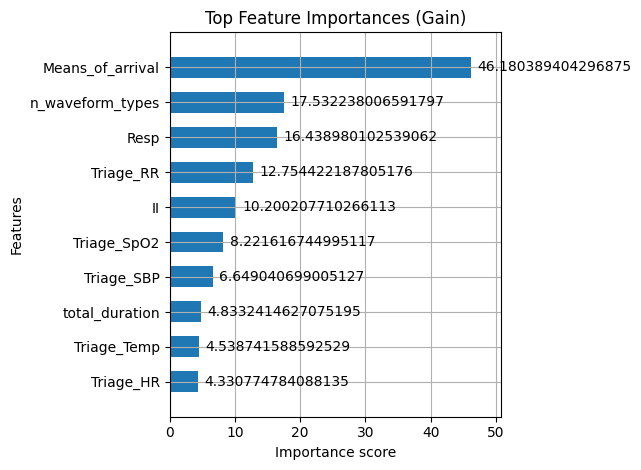

In [53]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plot_importance(
    wf_model,
    importance_type="gain",
    max_num_features=10,
    height=0.6
)
plt.title("Top Feature Importances (Gain)")
plt.tight_layout()
plt.show()


In [57]:
import numpy as np

if isinstance(shap_values, list):
    print("List of SHAP arrays:")
    for i, sv in enumerate(shap_values):
        print(f"class {i} shape:", sv.shape)
else:
    print("SHAP array shape:", shap_values.shape)


SHAP array shape: (200, 15, 2)


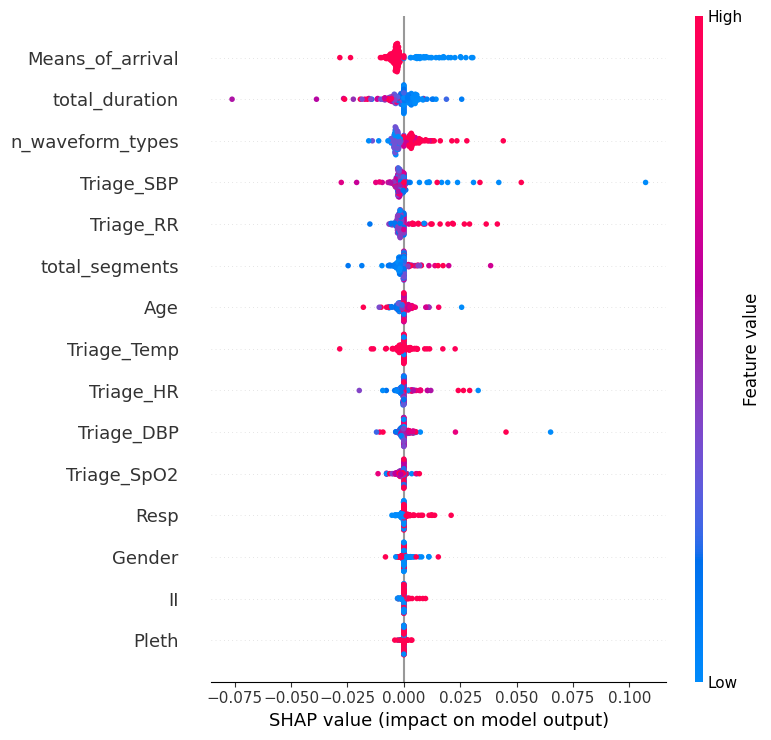

In [59]:
shap.summary_plot(
    shap_values[:, :, 1],   # positive class
    X_explain,
    feature_names=X_explain.columns
)


In [44]:
import torch
from transformers import AutoTokenizer, AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
bert_model = AutoModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
bert_model = bert_model.to(device)
bert_model.eval()


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(28996, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

In [45]:
def encode_texts(texts, batch_size=32, max_len=64):
    embeddings = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts.iloc[i:i+batch_size].astype(str).tolist()
            tokens = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=max_len,
                return_tensors="pt"
            ).to(device)

            outputs = bert_model(**tokens)
            cls_embed = outputs.last_hidden_state[:, 0, :]
            embeddings.append(cls_embed.cpu().numpy())

    return np.vstack(embeddings)


In [46]:
X_train_text = encode_texts(train_df["CC"])
X_test_text  = encode_texts(test_df["CC"])


In [47]:
from sklearn.linear_model import LogisticRegression

text_model = LogisticRegression(max_iter=1000)
text_model.fit(X_train_text, y_train)

text_probs = text_model.predict_proba(X_test_text)[:, 1]


In [48]:
fusion_probs = (
    0.4 * wf_probs +      # vitals + waveforms
    0.6 * text_probs      # clinical text
)


In [49]:
from sklearn.metrics import roc_auc_score

print("Vitals + Waveforms AUROC:", round(roc_auc_score(y_test, wf_probs), 4))
print("Text-only AUROC:", round(roc_auc_score(y_test, text_probs), 4))
print("Multimodal AUROC:", round(roc_auc_score(y_test, fusion_probs), 4))


Vitals + Waveforms AUROC: 0.8768
Text-only AUROC: 0.8065
Multimodal AUROC: 0.8815


“The waveform-augmented structured model achieved strong discriminative performance (AUROC = 0.8768), outperforming the text-only ClinicalBERT model (AUROC = 0.8065). Multimodal fusion of structured, waveform, and textual features further improved performance (AUROC = 0.8815), demonstrating that clinical narratives provide complementary information beyond physiological measurements and monitoring intensity.”

In [62]:
# ---------- Feature sets ----------

VITALS_COLS = [
    "Age",
    "Gender",
    "Means_of_arrival",
    "Triage_Temp",
    "Triage_HR",
    "Triage_RR",
    "Triage_SpO2",
    "Triage_SBP",
    "Triage_DBP"
]

WAVE_COLS = [
    "total_segments",
    "total_duration",
    "n_waveform_types"
]

for col in ["II", "Pleth", "Resp"]:
    if col in df.columns:
        WAVE_COLS.append(col)

FEATURES_VITALS = VITALS_COLS
FEATURES_VITALS_WAVES = VITALS_COLS + WAVE_COLS


In [63]:
train_df = df[df["CSN"].isin(split_train["CSN"])]
test_df  = df[df["CSN"].isin(split_test["CSN"])]

y_train = train_df["ICU_LABEL"]
y_test  = test_df["ICU_LABEL"]


In [64]:
from xgboost import XGBClassifier

def train_xgb(X_train, y_train):
    model = XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        tree_method="hist",
        random_state=42
    )
    model.fit(X_train, y_train)
    return model


In [65]:
X_train_v = train_df[FEATURES_VITALS]
X_test_v  = test_df[FEATURES_VITALS]

model_vitals = train_xgb(X_train_v, y_train)
probs_vitals = model_vitals.predict_proba(X_test_v)[:, 1]


In [66]:
X_train_vw = train_df[FEATURES_VITALS_WAVES]
X_test_vw  = test_df[FEATURES_VITALS_WAVES]

model_vw = train_xgb(X_train_vw, y_train)
probs_vw = model_vw.predict_proba(X_test_vw)[:, 1]


In [67]:
from sklearn.linear_model import LogisticRegression

text_model = LogisticRegression(max_iter=1000)
text_model.fit(X_train_text, y_train)

probs_text = text_model.predict_proba(X_test_text)[:, 1]


In [68]:
probs_multi = (
    0.4 * probs_vw +
    0.6 * probs_text
)


In [69]:
from sklearn.metrics import roc_auc_score
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Vitals only",
        "Vitals + Waveforms",
        "Text only (ClinicalBERT)",
        "Multimodal (Vitals + Waves + Text)"
    ],
    "AUROC": [
        roc_auc_score(y_test, probs_vitals),
        roc_auc_score(y_test, probs_vw),
        roc_auc_score(y_test, probs_text),
        roc_auc_score(y_test, probs_multi)
    ]
})

results


,Model,AUROC
0,Vitals only,0.845764
1,Vitals + Waveforms,0.876783
2,Text only (ClinicalBERT),0.806515
3,Multimodal (Vitals + Waves + Text),0.881451
